In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'k')

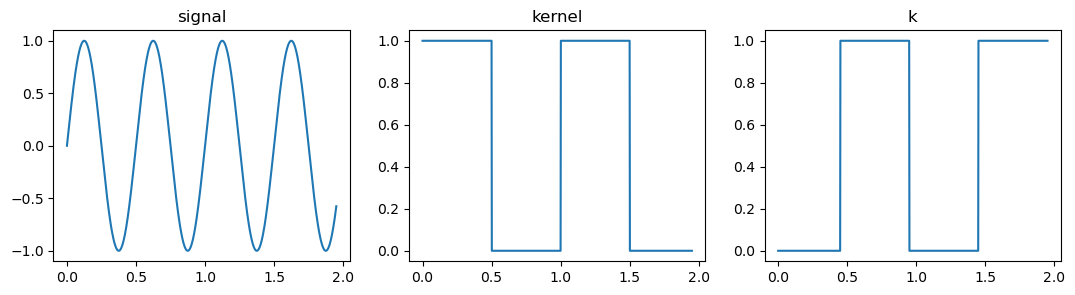

In [102]:
fs = 512
N = 1000
t = np.arange(N) / fs

signal = np.sin(2 * np.pi * 2 * t)
kernel = np.sin(2 * np.pi * 1 * t) >= 0

k = kernel.copy()
k = k[::-1]

conv_out = []

start = 0
end = 1

while start < N:
    signal_chunk = signal[start:end]
    kernel_chunk = k[-end:]
    if len(kernel_chunk) != len(signal_chunk):
        kernel_chunk = kernel_chunk[:len(signal_chunk)]

    dot_prod = np.dot(signal_chunk, kernel_chunk)
    conv_out.append(dot_prod)

    if end >= len(kernel):
        start += 1
        end += 1
    else:
        end += 1

lib_conv = np.convolve(signal, kernel, mode='full')

# FFT convolution
S_pad = np.fft.rfft(signal, n=N*2 - 1)
K_pad = np.fft.rfft(kernel, n=N*2 - 1)
freq_conv_padded = np.fft.irfft(S_pad * K_pad)

S = np.fft.rfft(signal)
K = np.fft.rfft(kernel)
freq_conv_interpolated = np.fft.irfft(S * K, n=N*2 - 1)

plt.figure(figsize=(13, 3))

plt.subplot(131)
plt.plot(t, signal)
plt.title("signal")

plt.subplot(132)
plt.plot(t, kernel)
plt.title("kernel")

plt.subplot(133)
plt.plot(t, k)
plt.title("k")


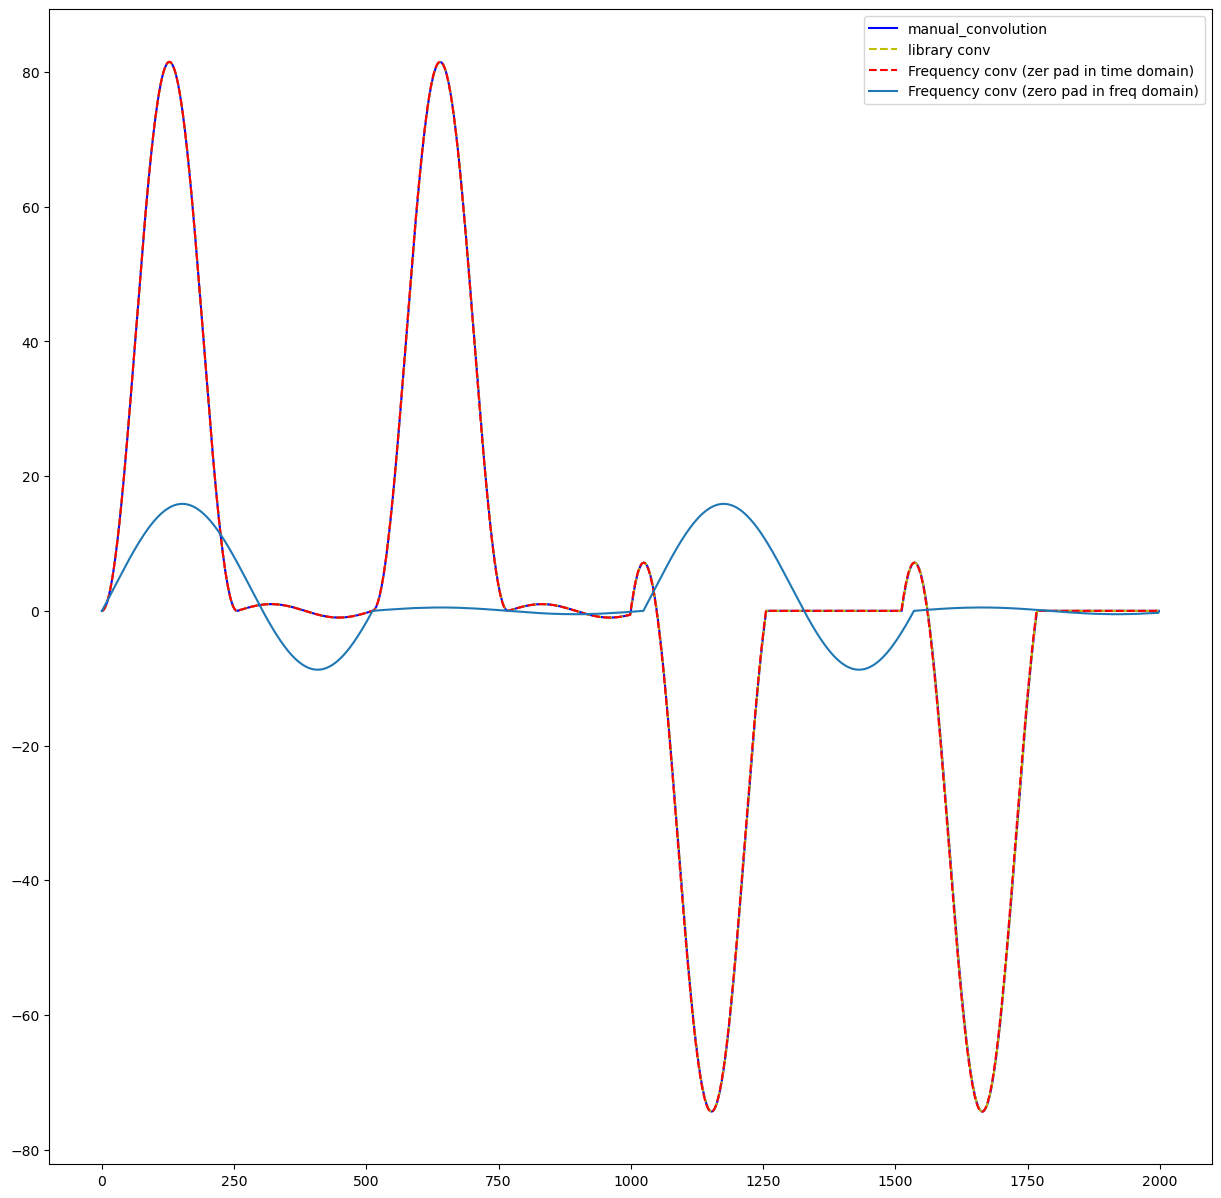

In [105]:
plt.figure(figsize=(15, 15))
plt.plot(np.array(conv_out), 'b', label='manual_convolution')
plt.plot(lib_conv, 'y--', label='library conv')
plt.plot(freq_conv_padded, 'r--', label='Frequency conv (zer pad in time domain)')
plt.plot(freq_conv_interpolated, label='Frequency conv (zero pad in freq domain)')
plt.plot()
plt.legend()